
<h1 align=center> Protokoll H1 </h1>
<h4 align=center> Gruppe 8 </h4>
<h3 align=center> Fynn Kanja 3780065, Valentino D’Agosto 3763229 </h3>
<h4 align=center> 11.04.2025 </h4>

## Inhaltsverzeichnis
- [1. Motivation](#1-motivation)
- [2. Aufgaben](#2-aufgaben)

## 1. Motivation
Ziel dieses Versuchs ist es, die Frequenz, Dämpfungskonstante sowie die Beschleunigungskomponenten des selber gebauten Smartphone-Pendels experimentell zu bestimmen. Des Weiteren werden mithilfe der theoretischen Grundlagen Erwartungswerte berechnet und diese mit den experimentell bestimmten Werten verglichen. Das Experiment selber wurde mehrfach durchgeführt und die Werte des am besten gelungenen Versuchs werden für das Protokoll genutzt.

## 2. Aufgaben
Für die Messung der Daten wurde ein Handy mit der Phyphox App genutzt. Mithilfe der App kann man die Rohdaten aus den verschiedensten Sensoren auslesen, die in einem Smartphone verbaut sind. Während des Experiments wurden Beschleunigung, lineare Beschleunigung mit dem Beschleunigungssensor und Winkelgeschwindigkeit mithilfe des Gyroskopsensors auf allen drei Achsen gleichzeitig gemessen.

Der Aufbau des Experiments bestand, wie in Abbildung \ref{aufbau} zu sehen, aus einem Smartphone, welches an zwei parallelen Fäden, wie bei einer Schaukel, um die Rotation während des Pendels zu minimieren, an einem Regenschirm befestigt wurde. Dabei zeigte die Handyoberfläche parallel zum Boden den Einfluss des Luftwiderstandes zu minimieren. Somit befindet sich die positive z-Achse in Richtung Boden, die positive y-Achse zeigt nach links und die positive x-Achse zur Richtung der Kamera. Die gesamte Pendellänge mit Handyhülle und Fadenlänge betrug 93 cm, wobei die Fäden 92 cm lang waren.

Bei Beginn der Messung befand sich das System in der Ruhelage und wurde erst danach ausgelenkt, damit das Gyroskop kalibriert war und den Wert 0 in der Ruhelage anzeigt. Beim Auslenken wurde nur um einen kleinen Winkel ausgelenkt, damit man das Pendel vereinfacht als mathematisches Pendel betrachten kann, da die Kleinwinkelnäherung angewendet werden kann. Beim Loslassen wurde versucht, dem Smartphone möglichst wenig Drehung und Schwung mitzugeben, sodass sich das Handy beim Pendeln nicht dreht oder die Messwerte verfälscht. Zur Minimierung möglicher Messfehler wurde das Pendel zunächst für 20 Sekunden eingeschwungen, um möglichst reine Messdaten zu erhalten.

Während des insgesamt 143 Sekunden andauernden Versuchs wurden Messdaten aufgezeichnet, die anschließend analysiert wurden.

<img src="figures/Versuchsaufbau_H1.jpg" alt="Abbildung 1: Aufbau des Pendelversuchs" width="80%" align="center" id="aufbau" />
<h5 align=center> Abbildung 1: Aufbau des Pendelversuchs </h5>

## Berechnung der Pendelfrequenz
Für ein einfaches mathematisches Pendel, wo Fadenmasse, Reibung sowie Luftwiderstand vernachlässigt werden können, gilt

$$T = 2\pi\cdot\sqrt{\frac{l}{g}}$$

Diese Formel lässt sich mit $f = \frac{1}{T}$ einfach nach der Frequenz umstellen

$$f = \frac{1}{2\pi} \cdot \sqrt{\frac{g}{l}}$$

wobei $g \text{ als } 9,81 \frac{m}{s^2}$ angenommen wird. Mit der gemessenen Fadenlänge $l = 0,93m$ ergibt sich somit eine theoretische Frequenz von $f=0,5169$ Hz, was den aus den Daten ermittelten Frequenzen sehr nahekommt. Von den Messabweichungen liegen alle Frequenzen unter $\pm0,05$ Hz und $f_{a_{lin}}$ und $f_{gyro}$ sogar unter $\pm0,01$ Hz

Dämpfungskonstante delta: 0.0039 1/s


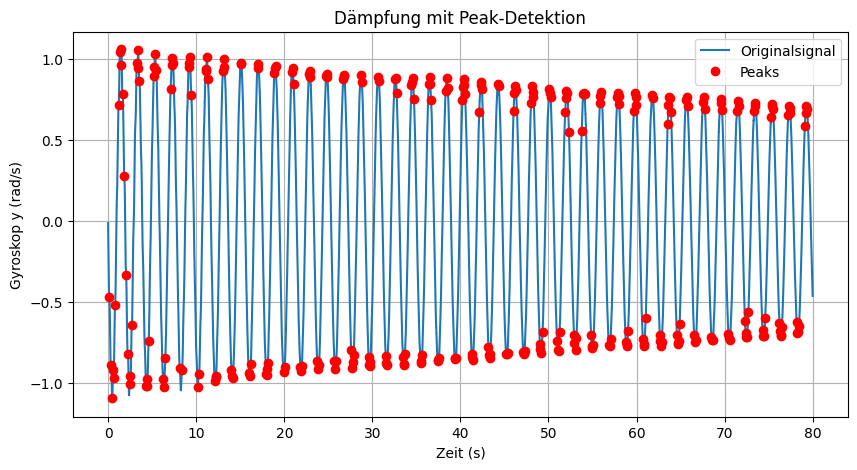

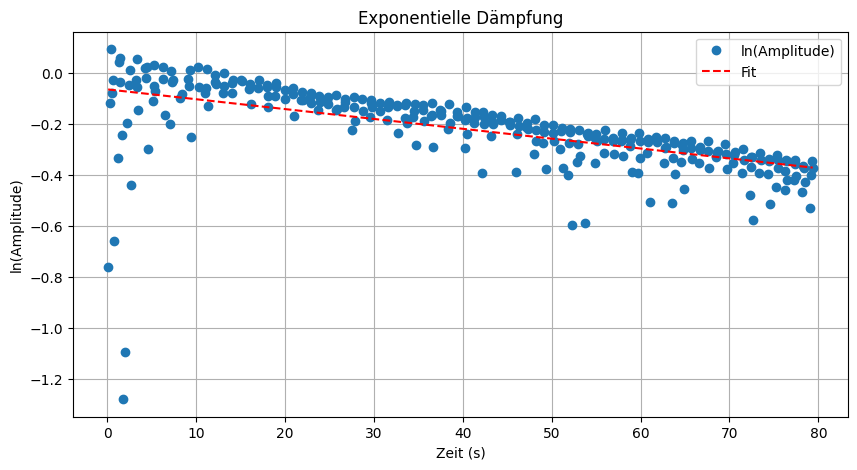

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

start_time = 20.3
end_time = 100.3

# CSV-Datei laden und Zeitfenster anwenden
df = pd.read_csv("data/Gyroscope.csv")
df = df[(df['Time (s)'] >= start_time) & (df['Time (s)'] <= end_time)]
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

t = df['Zeit_Angepasst']
y = df['Gyroscope y (rad/s)']

# Peaks finden
peaks, _ = find_peaks(y, distance=30)  # distance ggf. anpassen
t_peaks = t.iloc[peaks]
y_peaks = y.iloc[peaks]

# Logarithmus der Amplituden
log_amplituden = np.log(np.abs(y_peaks))

# Fit-Funktion
def linear(t, a, delta):
    return a - delta * t

# Curve-Fit anwenden
params, _ = curve_fit(linear, t_peaks, log_amplituden)
a_fit, delta = params

print(f"Dämpfungskonstante delta: {delta:.4f} 1/s")

# Plot: Originalsignal mit Peaks
plt.figure(figsize=(10, 5))
plt.plot(t, y, label="Originalsignal")
plt.plot(t_peaks, y_peaks, "ro", label="Peaks")
plt.xlabel("Zeit (s)")
plt.ylabel("Gyroskop y (rad/s)")
plt.legend()
plt.title("Dämpfung mit Peak-Detektion")
plt.grid()
plt.show()

# Plot: Logarithmus der Amplituden
plt.figure(figsize=(10, 5))
plt.plot(t_peaks, log_amplituden, "o", label="ln(Amplitude)")
plt.plot(t_peaks, linear(t_peaks, *params), "r--", label="Fit")
plt.xlabel("Zeit (s)")
plt.ylabel("ln(Amplitude)")
plt.title("Exponentielle Dämpfung")
plt.legend()
plt.grid()
plt.show()
